Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.XVQXGX_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.XVQXGX_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training...
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 412ms/step - accuracy: 0.5975 - loss: 1.5103 - val_accuracy: 0.8193 - val_loss: 0.6351
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 361ms/step - accuracy: 0.9042 - loss: 0.3567 - val_accuracy: 0.8356 - val_loss: 0.5123
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 349ms/step - accuracy: 0.9592 - loss: 0.1815 - val_accuracy: 0.8370 - val_loss: 0.4985

--- Upload an image of a dog or cat ---


Saving Screenshot 2026-03-13 at 2.33.08 PM.png to Screenshot 2026-03-13 at 2.33.08 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step


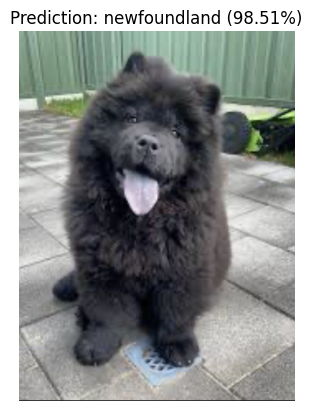

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import gc
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from google.colab import files # For image upload in Colab

# --- 1. Environment Setup ---
tf.keras.backend.clear_session()
gc.collect()

# --- 2. Load Dataset ---
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
CLASS_NAMES = ds_info.features["label"].names
IMG_SIZE = 128
BATCH_SIZE = 32

# --- 3. Preprocessing ---
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # We apply preprocess_input inside the map function or model
    image = preprocess_input(image)
    return image, label

# Fixed the bullet point characters to standard periods
train_ds = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- 4. Build Model (Transfer Learning) ---
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False # Freeze the pre-trained weights

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- 5. Train Model ---
print("Starting training...")
model.fit(train_ds, epochs=3, validation_data=test_ds)

# --- 6. Prediction with User Uploaded Image ---
print("\n--- Upload an image of a dog or cat ---")
uploaded = files.upload()

for filename in uploaded.keys():
    # Load and process the uploaded image
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for prediction
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(img_resized, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    # Predict
    preds = model.predict(img_preprocessed)
    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    # Display Result
    plt.imshow(img)
    plt.title(f"Prediction: {CLASS_NAMES[class_idx]} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()